# 🏠 Tehran House Price Prediction

### Project Overview 👀
This project applies Machine Learning techniques to predict house prices in Tehran based on a dataset of approximately 4,000 real estate listings. Using **Multiple Linear Regression**, the model estimates the price of a property given its specific features.

# 1. 📦 Importing Libraries and Loading Data
Here, we import the necessary libraries for data *manipulation*, *visualization*, and *machine learning*. We also load the dataset into a *Pandas DataFrame*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Set a clean, minimal dark theme for visualization
plt.style.use('dark_background')

# Load the dataset
df = pd.read_csv('housePrice.csv')
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


## 2. 🧹 Data Cleaning and Preprocessing
Real-world data is often messy. Here, we:
- Convert the 'Area' column to numeric values.
- Drop/Remove rows with missing values (missing addresses).
- Remove outliers in the 'Area' column (properties listed as > 1000 sqm).
- Drop/Remove the 'Price(USD)' column to prevent data leakage.

In [2]:
# 1. Convert 'Area' to numeric
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

# 2. Drop rows with missing values
df.dropna(subset=['Address', 'Area'], inplace=True)

# 3. Handling outliers: Keep houses with an area less than 1000 sq meters
df = df[df['Area'] < 1000]

# 4. Drop the USD price column
df.drop('Price(USD)', axis=1, inplace=True)

# Check the cleaned dataset shape and info
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (3450, 7)


## 3. 🛠️ Feature Encoding
Machine learning models require numerical input. We use One-Hot Encoding to convert categorical variables (like 'Address' and boolean columns such as 'Parking', 'Elevator') into a numerical format for training.

In [3]:
# Convert categorical variables into dummy/indicator variables
# drop_first=True helps avoid the dummy variable trap (multicollinearity)
df_encoded = pd.get_dummies(df, columns=['Address', 'Parking', 'Warehouse', 'Elevator'], drop_first=True)

# Define our features (X) and target (y)
x = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

## 4. ⚙️ Train/Test Split and Feature Scaling
We split the dataset into **training (80%)** and **testing (20%)** sets to evaluate the model on unseen data. Then, we apply *standard scaling* to normalize the *feature distributions*, which improves the performance and stability of linear models.

In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. 💡 Model Training: Multiple Linear Regression
We initialize and train a Multiple Linear Regression model using the scaled training data. The model learns the optimal weights for each feature to predict the house price.

In [5]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed successfully ✅")

Model training completed successfully ✅


## 6. 🎯 Evaluation and Visualization
Finally, we test our model's performance on the test data. We calculate metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2 Score) to quantify accuracy. A scatter plot visualizes the actual versus predicted prices.

R2 Score: 0.7022
Mean Absolute Error (MAE): 2,163,641,088 Toman
Mean Squared Error (MSE): 22,528,972,100,547,846,144



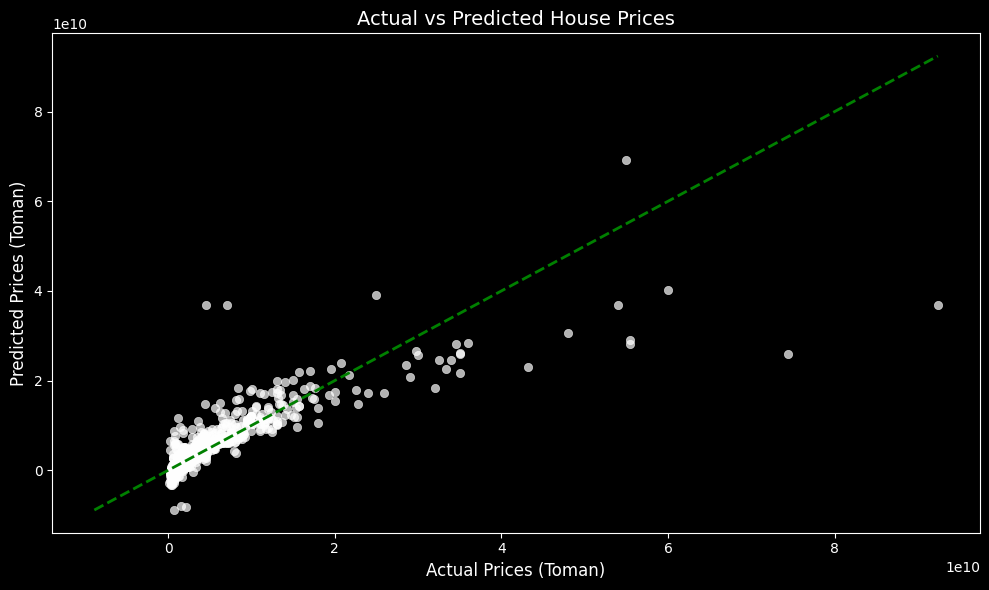

In [7]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R2 Score: {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:,.0f} Toman')
print(f'Mean Squared Error (MSE): {mse:,.0f}')
print()

# Visualize Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='white')

# Plot the perfect prediction line
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='green', lw=2, linestyle='--')

plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.xlabel('Actual Prices (Toman)', fontsize=12)
plt.ylabel('Predicted Prices (Toman)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. 💾 Model Export
To make this model useful in a real-world application (a real estate pricing API or web app), we export the trained linear regression model and the standard scaler using `joblib`. This allows us to load and use them later without needing to retrain the model.

In [8]:
# Export the trained model
joblib.dump(model, 'tehran_house_price_model.pkl')

# Export the standard scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler successfully exported and svaed to disk ✅")

Model and Scaler successfully exported and svaed to disk ✅
